All Dependencies

In [36]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from glob import glob

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Mount Drive (Execute only if using Colab)

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load Dataset

In [ ]:
file_path = "/content/drive/MyDrive/Tasks/Classifier/dataset/dataset"

# Initialise parameters
IMG_SIZE = 150
BATCH_SIZE = 64
EPOCHS = 40
NUM_CLASSES = 3
CLASS_NAMES = ["no", "sphere", "vort"]
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

def load_dataset(dataset_dir):

  X_train = []
  y_train = []
  X_test = []
  y_test = []

  for d in os.listdir(dataset_dir):
    if d == "train":
      train_dir = os.path.join(dataset_dir, d)
      idx = 0
      for class_name in CLASS_NAMES:
        class_dir = os.path.join(train_dir, class_name)
        for img in os.listdir(class_dir):
          if img.endswith(".npy"):
            img_path = os.path.join(class_dir, img)
            img_data = np.load(img_path)
            img_data = np.transpose(img_data, (1, 2, 0))
            X_train.append(img_data)
            y_train.append(idx)
        idx += 1
    if d == "val":
      test_dir = os.path.join(dataset_dir, d)
      idx = 0
      for class_name in CLASS_NAMES:
        class_dir = os.path.join(test_dir, class_name)
        for img in os.listdir(class_dir):
          if img.endswith(".npy"):
            img_path = os.path.join(class_dir, img)
            img_data = np.load(img_path)
            img_data = np.transpose(img_data, (1, 2, 0))
            X_test.append(img_data)
            y_test.append(idx)
        idx += 1

  X_train = np.array(X_train)
  y_train = np.array(y_train)
  X_test = np.array(X_test)
  y_test = np.array(y_test)
  return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_dataset(file_path)

# Cast to float32
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

# Normalize
train_mean = X_train.mean()
train_std = X_train.std()
X_train = (X_train - train_mean) / (train_std + 1e-8)
X_test = (X_test - train_mean) / (train_std + 1e-8)

# Split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=SEED)

print(f"After norm — Mean: {X_train.mean():.4f}, Std: {X_train.std():.4f}")
print(f"Shape: {X_train.shape}, dtype: {X_train.dtype}")

After norm — Mean: -0.0002, Std: 0.9997
Shape: (27000, 150, 150, 1), dtype: float32


Visualize Samples

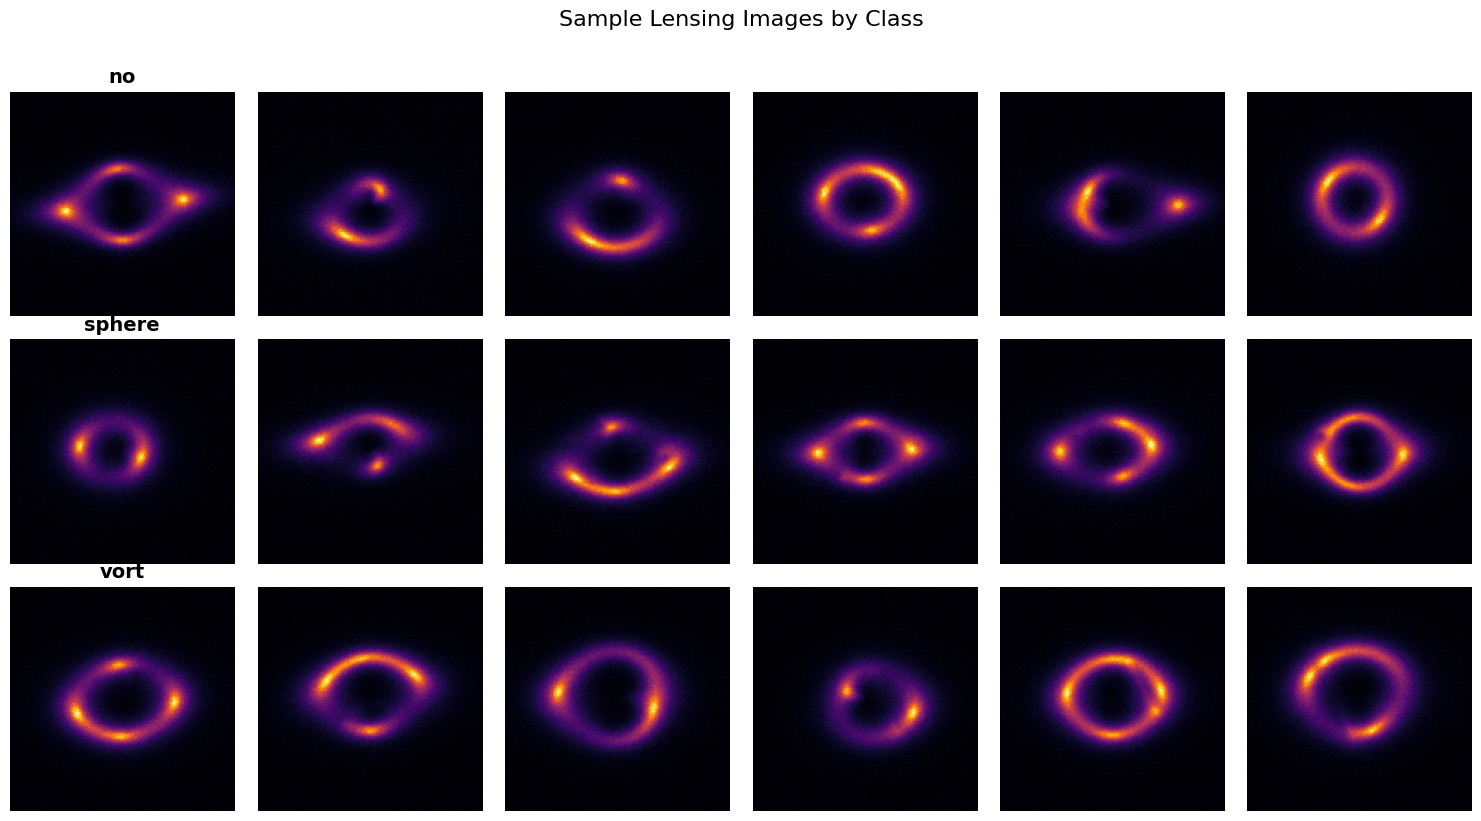

In [ ]:
fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for row, (cls_idx, cls_name) in enumerate(enumerate(CLASS_NAMES)):
    mask = y_train == cls_idx
    samples = X_train[mask][:6]
    for col in range(6):
        axes[row, col].imshow(samples[col, :, :, 0], cmap='inferno')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls_name, fontsize=14, fontweight='bold')
plt.suptitle("Sample Lensing Images by Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Build Model

In [42]:
def build_model(img_size, num_channels, num_classes):
    inputs = keras.Input(shape=(img_size, img_size, num_channels))

    # Block 1
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    # Block 4
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name="DeepLense_Classifier")

num_channels = X_train.shape[-1]
model = build_model(IMG_SIZE, num_channels, NUM_CLASSES)
model.summary()

model.compile(
    optimizer=optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Model: "DeepLense_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,89

 Total params: 617,699 (2.36 MB)

 Trainable params: 616,291 (2.35 MB)

 Non-trainable params: 1,408 (5.50 KB)

Train Model

In [43]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        callbacks.EarlyStopping(patience=12, restore_best_weights=True,
                                monitor='val_accuracy', mode='max'),
        callbacks.ReduceLROnPlateau(factor=0.5, patience=5, verbose=1,
                                    monitor='val_loss', min_lr=1e-6),
    ],
    verbose=1
)

Epoch 1/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 64s 127ms/step - accuracy: 0.3418 - loss: 1.1054 - val_accuracy: 0.3317 - val_loss: 2.0901 - learning_rate: 3.0000e-04
Epoch 2/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 35s 82ms/step - accuracy: 0.3734 - loss: 1.0900 - val_accuracy: 0.3390 - val_loss: 1.6731 - learning_rate: 3.0000e-04
Epoch 3/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 35s 82ms/step - accuracy: 0.5458 - loss: 0.8869 - val_accuracy: 0.5337 - val_loss: 1.0589 - learning_rate: 3.0000e-04
Epoch 4/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 35s 82ms/step - accuracy: 0.7020 - loss: 0.6619 - val_accuracy: 0.4740 - val_loss: 1.4183 - learning_rate: 3.0000e-04
Epoch 5/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 35s 82ms/step - accuracy: 0.8160 - loss: 0.4615 - val_accuracy: 0.7037 - val_loss: 0.7570 - learning_rate: 3.0000e-04
Epoch 6/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 35s 82ms/step - accuracy: 0.8574 - loss: 0.3709 - val_accuracy: 0.7447 - val_loss: 0.7545 - learning_rate: 3.0000e-04
Epoch 7/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 35s 82ms/st

Plot Model

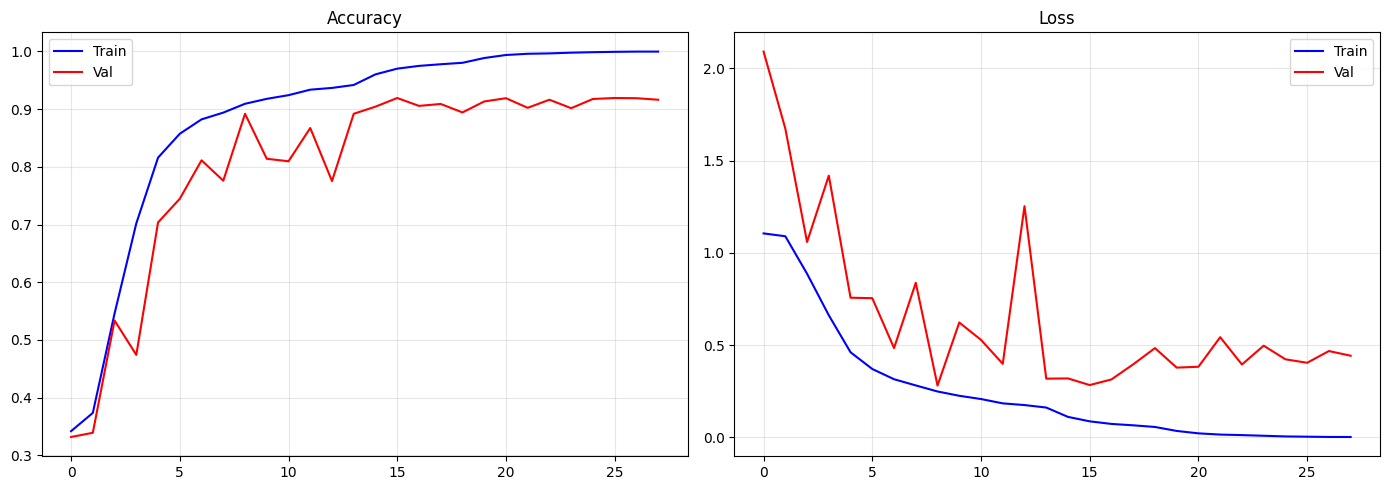

In [46]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))

a1.plot(acc, 'b', label='Train')
a1.plot(val_acc, 'r', label='Val')
a1.set_title('Accuracy')
a1.legend()
a1.grid(alpha=0.3)

a2.plot(loss, 'b', label='Train')
a2.plot(val_loss, 'r', label='Val')
a2.set_title('Loss')
a2.legend()
a2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

Test Model

235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
CLASSIFICATION REPORT
              precision    recall  f1-score   support

          no     0.8973    0.9612    0.9282      2500
      sphere     0.9100    0.8612    0.8849      2500
        vort     0.9186    0.9024    0.9104      2500

    accuracy                         0.9083      7500
   macro avg     0.9086    0.9083    0.9078      7500
weighted avg     0.9086    0.9083    0.9078      7500



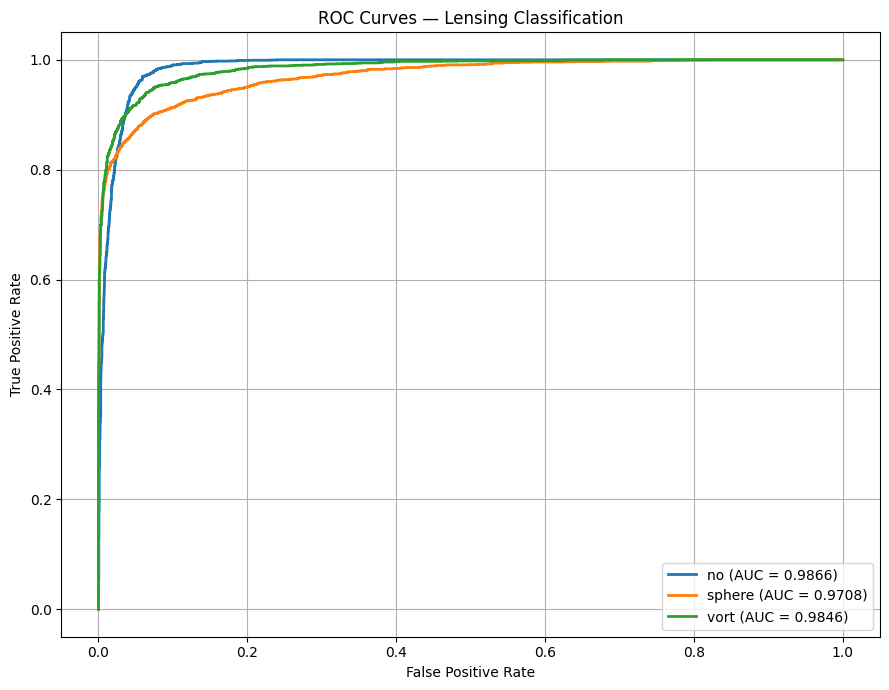


AUC SCORES:
  no                       : 0.9866
  sphere                   : 0.9708
  vort                     : 0.9846


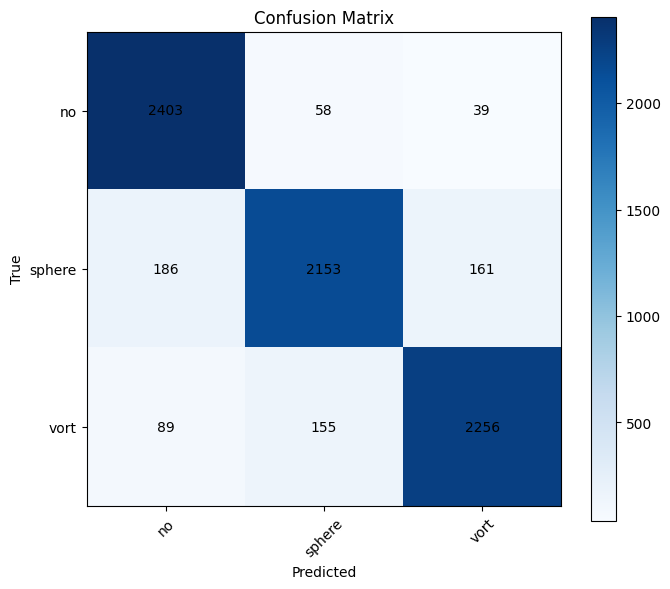

Model saved: lens_classifier.keras


In [47]:
y_proba = model.predict(X_test)
y_pred = np.argmax(y_proba, axis=1)

print("CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

y_bin = label_binarize(y_test, classes=[0, 1, 2])
fpr, tpr, roc_auc = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(9, 7))
for i in range(3):
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.4f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Lensing Classification')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

print("\nAUC SCORES:")
for i in range(NUM_CLASSES):
    print(f"  {CLASS_NAMES[i]:25s}: {roc_auc[i]:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
for i in range(3):
    for j in range(3):
        plt.text(j, i, str(cm[i,j]), ha='center', va='center')
plt.xticks([0,1,2], CLASS_NAMES, rotation=45)
plt.yticks([0,1,2], CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

model.save("lens_classifier.keras")
print("Model saved: lens_classifier.keras")